# Chapter 2 — Vector autoregressions

The executable counterpart of `docs/companion/03-ch2-vars.md`: the Minnesota bivariate VAR (example 1), the monthly Cholesky VAR (example 2), the steady-state prior (example 3), sign restrictions (examples 5–7) and the conditional forecast (example 8).

In [1]:
from pathlib import Path
import os
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from macrotoolkit import api as mtk
from macrotoolkit.run import REPO_ROOT as REPO   # never walk parent directories (HANDOFF warning)

HB = REPO / "examples" / "handbook"
HEAVY = os.environ.get("HANDBOOK_HEAVY") == "1"

def fit(name):
    """Fit an example spec (reused by hash if the run exists) and print its record."""
    run = mtk.fit(str(HB / name / "spec.yaml"))
    mc = run.mirror_check
    print(f"{name}: run {run.hash} | verdict {run.verdict} | {'; '.join(run.diagnostics['reasons'])}")
    print(f"  fit-time mirror check: max |Stan - Python| KF loglik = {mc['max_abs_diff']:.2e} over {mc['n_points']} prior draws")
    return run

def heavy(name):
    if not HEAVY:
        print(f"{name}: heavy example -- run with HANDBOOK_HEAVY=1 (a run session); skipped here.")
        return None
    return fit(name)


/root/.local/share/uv/tools/pytest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Example 1: the bivariate VAR(2) with a Minnesota prior, in recursive form

In [2]:
run = fit("ch2_bivar_minnesota")
run.param_table().round(4)

ch2_bivar_minnesota: run a620305f7c6e | verdict WARN | max R-hat 1.0197 > 1.01; min bulk/tail ESS (296/305) < 400
  fit-time mirror check: max |Stan - Python| KF loglik = 1.82e-12 over 5 prior draws


,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
a0_pi_y,-0.0115,-0.0793,0.0565,0.9985,479.2818,404.0266
b_pi_pi_1,1.3556,1.2496,1.4678,1.0042,362.0055,462.3938
b_pi_pi_2,-0.4184,-0.5304,-0.3152,1.0024,353.1698,369.7774
b_pi_y_1,0.1169,0.0073,0.2277,1.0129,429.3435,445.6881
b_pi_y_2,-0.0675,-0.1373,0.0002,0.9978,492.7569,460.1532
b_y_pi_1,0.1015,-0.0377,0.2401,1.0013,487.9712,312.2655
b_y_pi_2,-0.1875,-0.3307,-0.0451,1.0024,479.5368,364.2808
b_y_y_1,1.2344,1.1556,1.3326,1.0159,316.7375,357.2312
b_y_y_2,-0.4945,-0.5957,-0.4118,1.0038,420.5659,364.5508


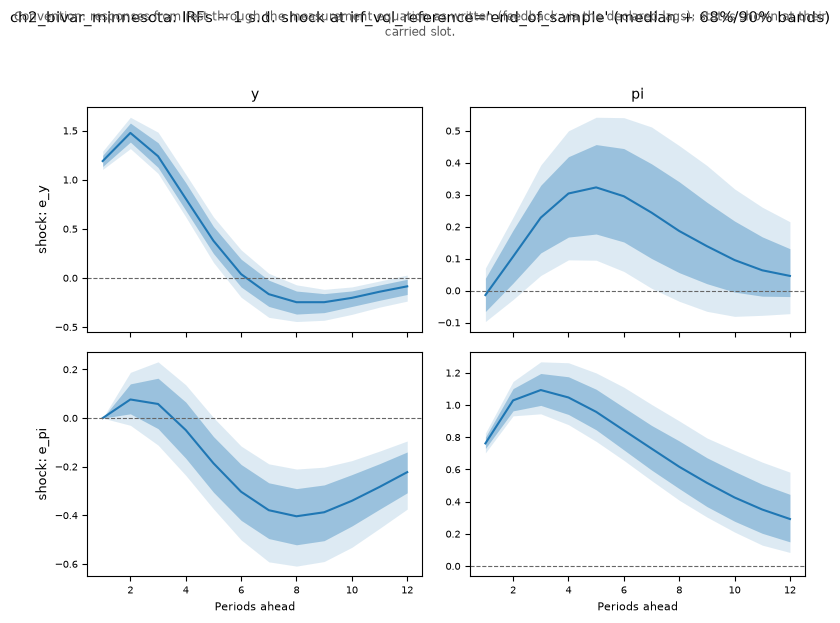

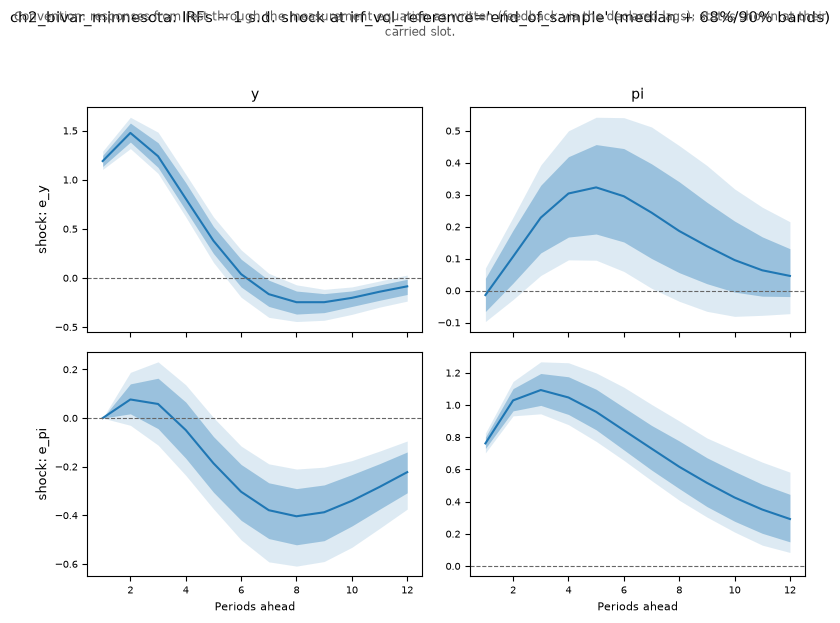

In [3]:
run.outputs().figure("irf")

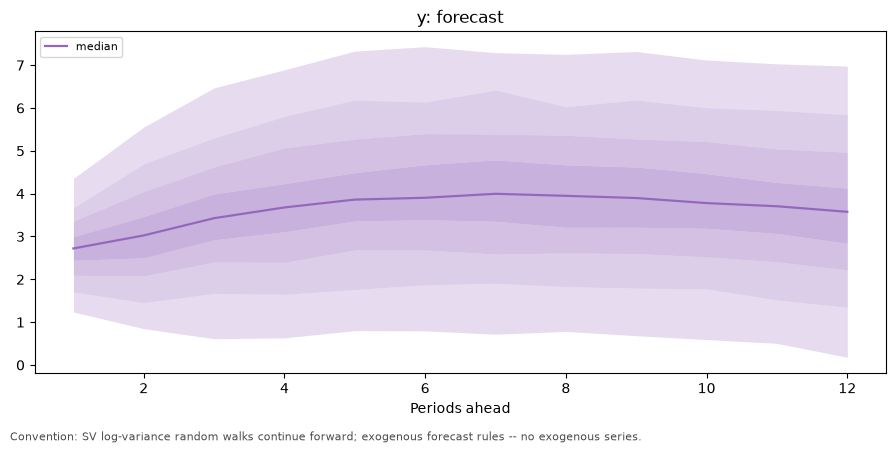

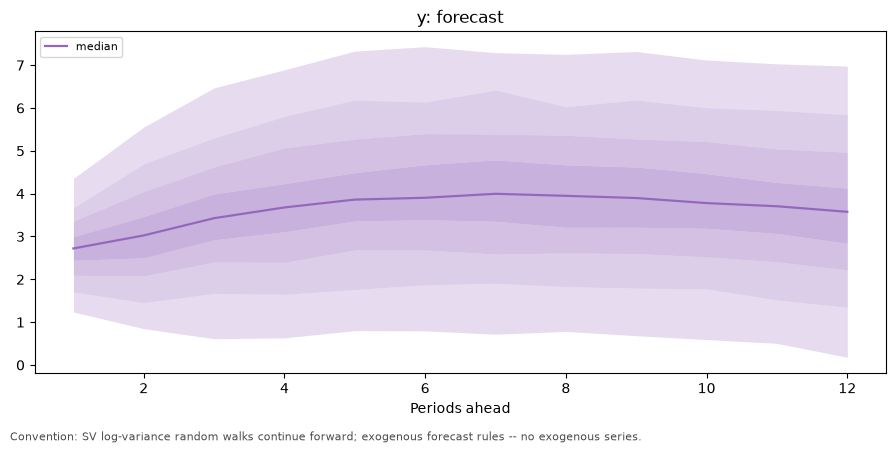

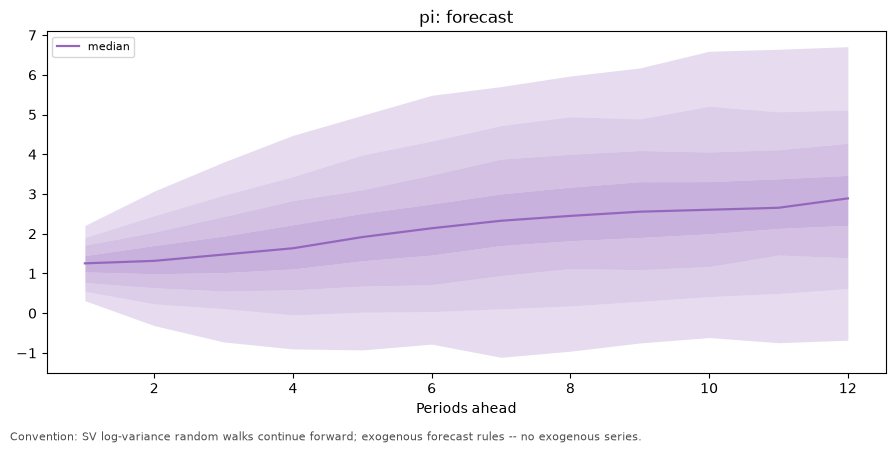

In [4]:
run.outputs().figure("fan")["y"]

## Example 2: the 4-variable monthly VAR — the engine's structural IRFs under the ordering are the Cholesky IRFs

In [5]:
run = fit("ch2_var4_monthly_cholesky")
run.param_table().round(4)

ch2_var4_monthly_cholesky: run 7247575d7872 | verdict WARN | 592 iteration(s) hit max_treedepth=10; max R-hat 1.0210 > 1.01; min bulk/tail ESS (215/265) < 400
  fit-time mirror check: max |Stan - Python| KF loglik = 7.04e-08 over 5 prior draws


,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
a0_bond10y_ffr,0.1917,-0.0520,0.4229,0.9982,481.4581,521.6631
a0_inflation_bond10y,0.2733,-0.2000,0.6905,1.0023,768.2872,415.2881
a0_inflation_ffr,0.4349,-0.0782,0.9418,1.0017,821.8090,416.6789
a0_inflation_unemployment,-0.1989,-0.7193,0.3288,1.0189,293.7102,339.7272
a0_unemployment_bond10y,0.1480,0.0154,0.2827,0.9993,754.6164,504.8783
a0_unemployment_ffr,-0.1564,-0.3113,-0.0143,1.0049,666.5075,488.4154
b_bond10y_bond10y_1,0.8928,0.7604,1.0248,1.0046,711.4867,409.4328
b_bond10y_bond10y_2,-0.0490,-0.1773,0.0770,0.9992,711.3999,539.0262
b_bond10y_ffr_1,-0.0183,-0.2134,0.1857,1.0031,553.3440,539.5412


impact medians of the bond-yield shock: {'ffr': 0.0, 'bond10y': 0.31, 'unemployment': 0.045, 'inflation': 0.074}


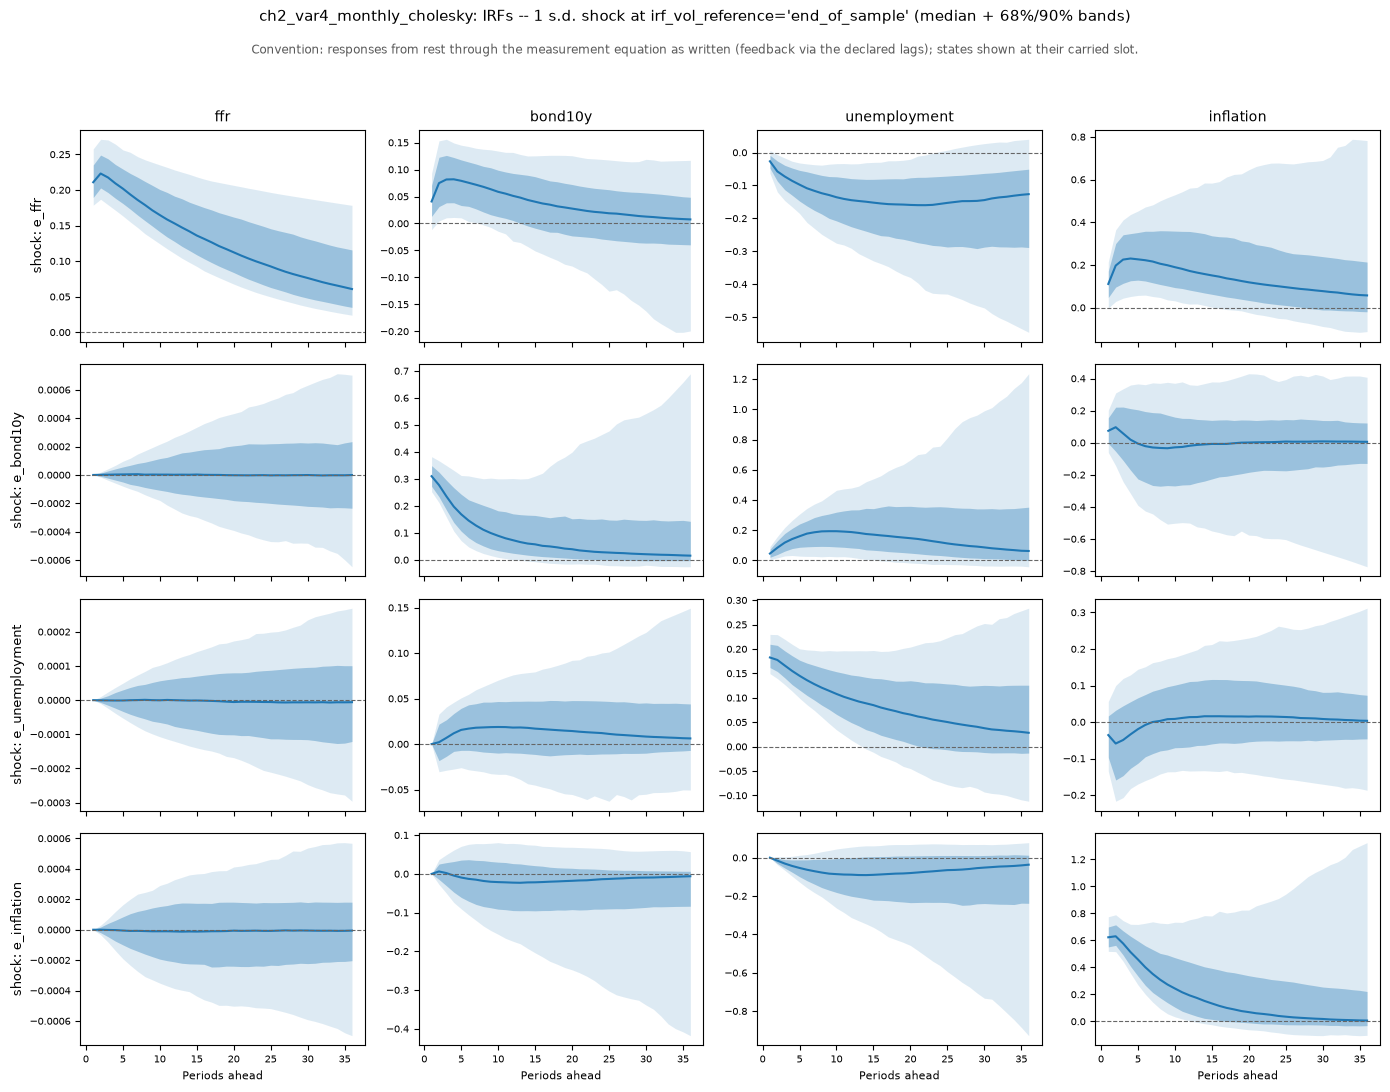

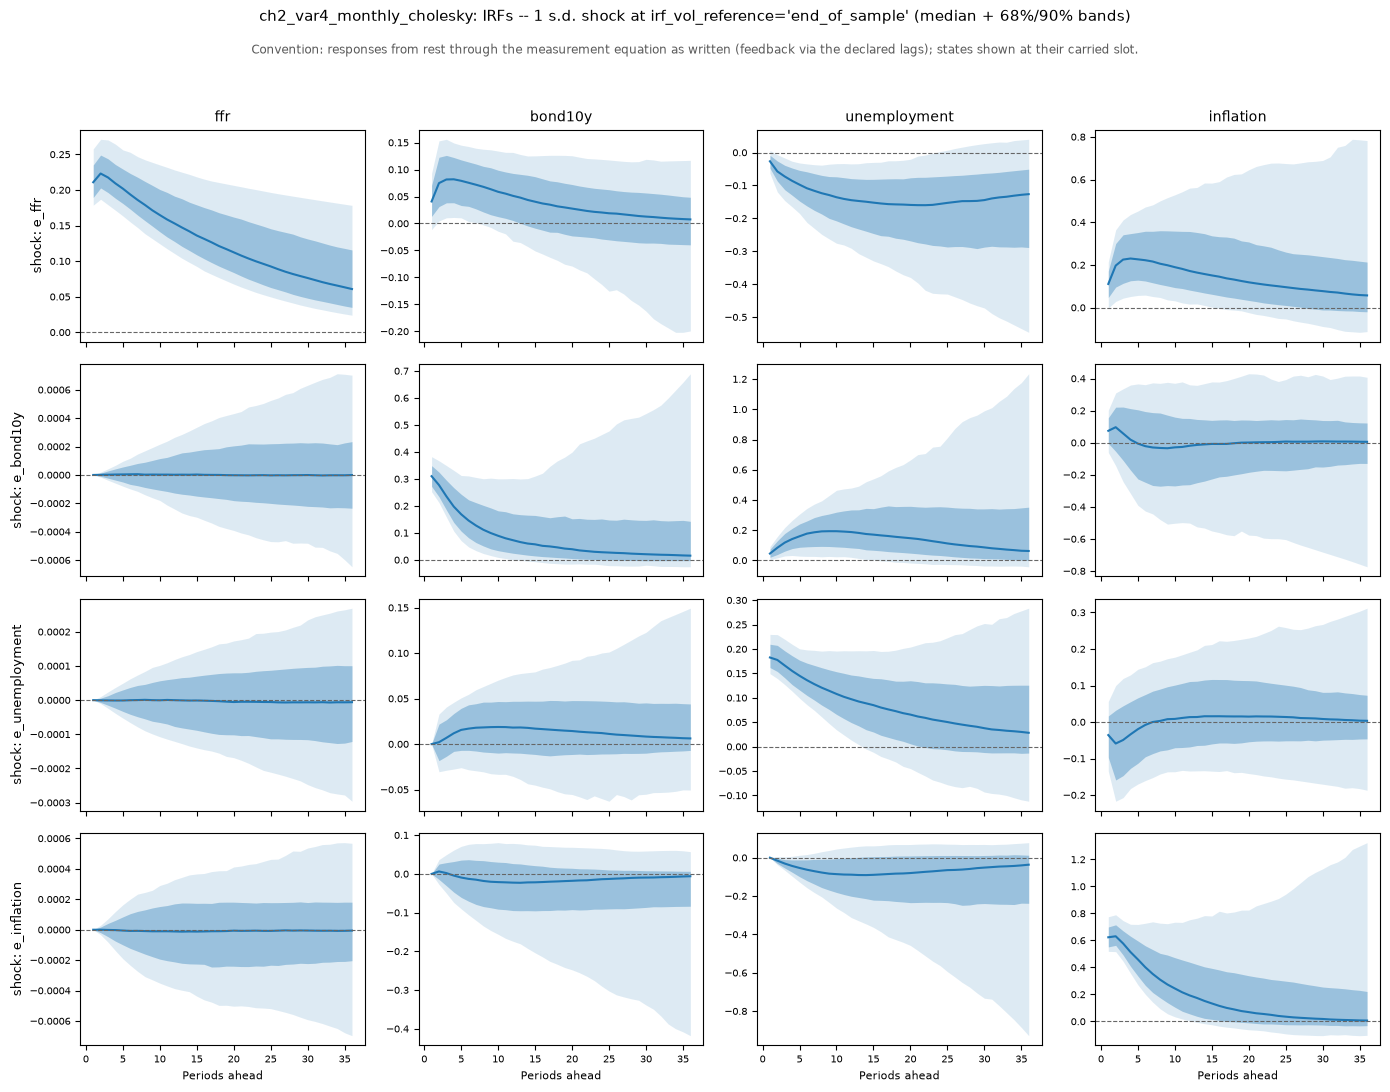

In [6]:
irf = run.outputs().compute("irf")
r = irf.responses["e_bond10y"]
print("impact medians of the bond-yield shock:", {o: round(float(np.median(r[o][:, 0])), 3) for o in r})
run.outputs().figure("irf")

## Example 3: the steady-state (Villani) prior — long-run means as constant states

In [7]:
run = fit("ch2_steady_state")
run.param_table().round(4)

ch2_steady_state: run fc2f0c3c4319 | verdict WARN | max R-hat 1.0125 > 1.01; min bulk/tail ESS (213/282) < 400
  fit-time mirror check: max |Stan - Python| KF loglik = 1.82e-12 over 5 prior draws


,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
a0_pi_y,-0.0038,-0.0655,0.0585,1.0001,429.6695,511.3578
b_pi_pi_1,1.3498,1.2586,1.4418,1.0093,464.6781,296.9588
b_pi_pi_2,-0.4052,-0.4942,-0.3221,1.0083,464.4831,281.9540
b_pi_y_1,0.1188,0.0137,0.2068,0.9983,329.7692,414.2601
b_pi_y_2,-0.0662,-0.1239,0.0039,0.9991,451.9235,385.9237
b_y_pi_1,0.0428,-0.1331,0.1992,1.0088,352.1689,351.4344
b_y_pi_2,-0.0270,-0.1819,0.1367,1.0062,355.7214,347.5493
b_y_y_1,1.3306,1.2387,1.4179,1.0013,674.8458,512.7079
b_y_y_2,-0.4746,-0.5670,-0.3831,1.0015,614.6601,513.6957


{'mu_y': 1.006, 'mu_pi': 0.999}


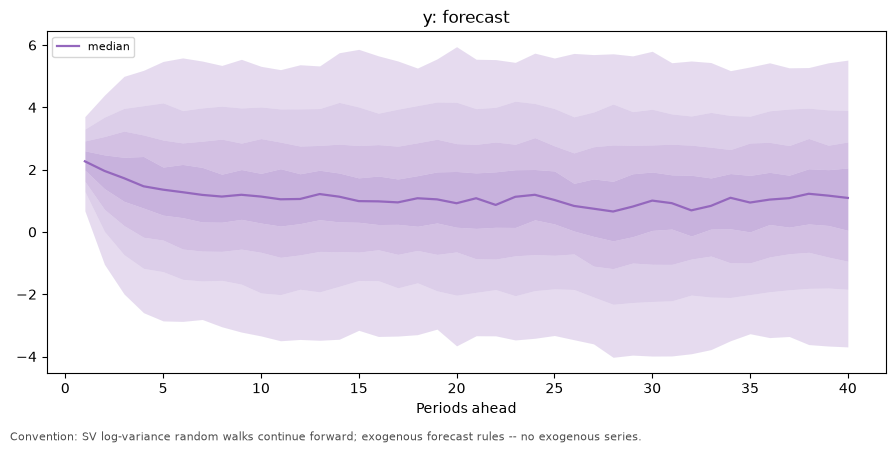

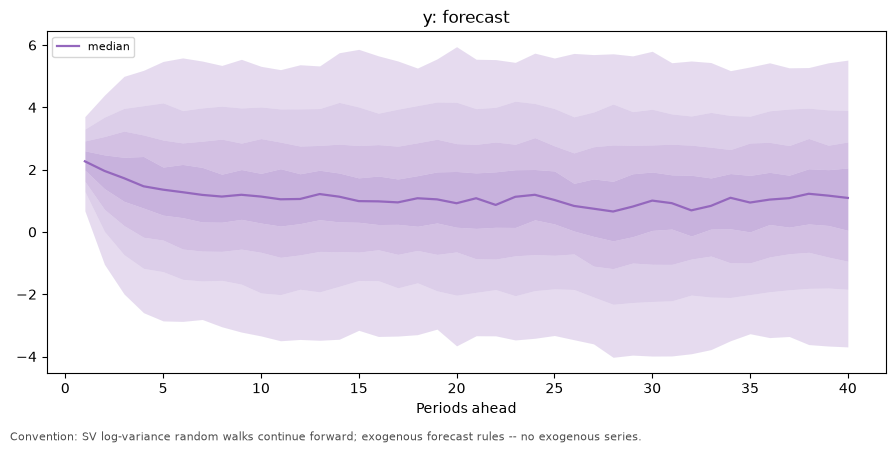

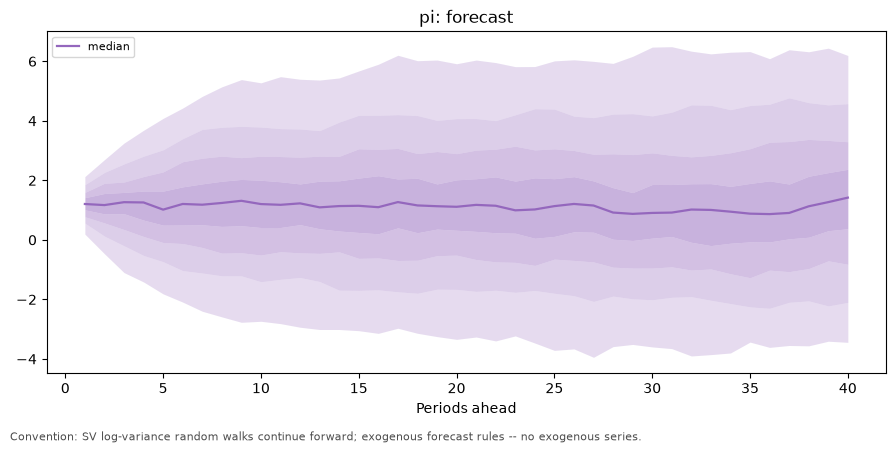

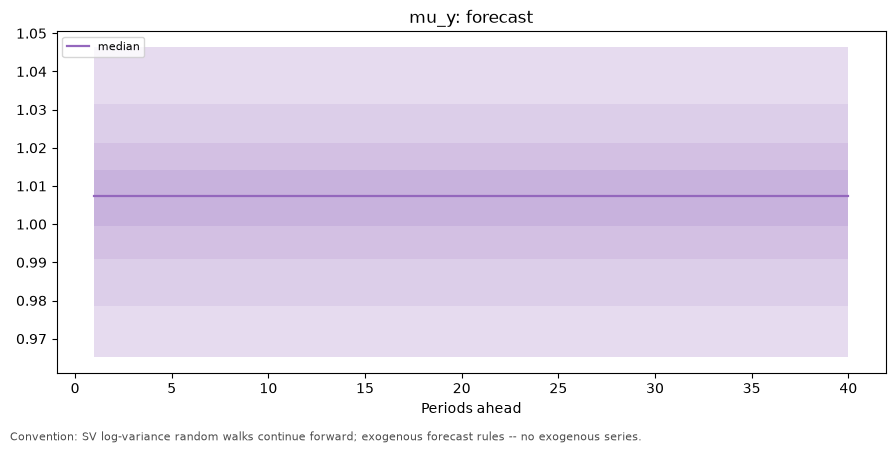

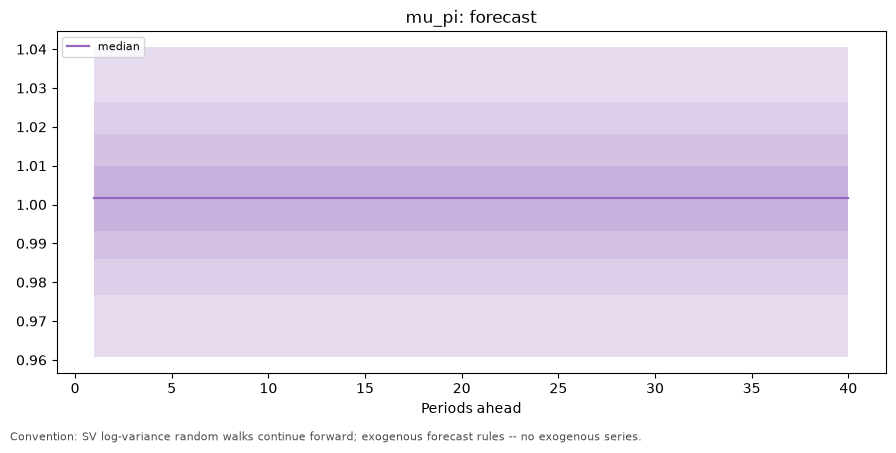

In [8]:
sd = run.outputs().compute("states")
print({k: round(float(np.median(v)), 3) for k, v in sd.states.items()})
run.outputs().figure("fan")["y"]

## Example 8: the Waggoner–Zha conditional forecast — inflation held at 1% for three quarters

In [9]:
run = fit("ch2_conditional")
run.param_table().round(4)

ch2_conditional: run d92813ddfb30 | verdict WARN | max R-hat 1.0197 > 1.01; min bulk/tail ESS (296/305) < 400
  fit-time mirror check: max |Stan - Python| KF loglik = 1.82e-12 over 5 prior draws


,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
a0_pi_y,-0.0115,-0.0793,0.0565,0.9985,479.2818,404.0266
b_pi_pi_1,1.3556,1.2496,1.4678,1.0042,362.0055,462.3938
b_pi_pi_2,-0.4184,-0.5304,-0.3152,1.0024,353.1698,369.7774
b_pi_y_1,0.1169,0.0073,0.2277,1.0129,429.3435,445.6881
b_pi_y_2,-0.0675,-0.1373,0.0002,0.9978,492.7569,460.1532
b_y_pi_1,0.1015,-0.0377,0.2401,1.0013,487.9712,312.2655
b_y_pi_2,-0.1875,-0.3307,-0.0451,1.0024,479.5368,364.2808
b_y_y_1,1.2344,1.1556,1.3326,1.0159,316.7375,357.2312
b_y_y_2,-0.4945,-0.5957,-0.4118,1.0038,420.5659,364.5508


conditional median GDP-growth path: [2.878, 3.135, 3.478] | unconditional: [2.843, 3.187, 3.572]
the inflation path reproduces (1, 1, 1) to 1.5e-07


<Axes: title={'center': 'GDP growth: conditional (blue, 5/50/95%) vs unconditional'}>

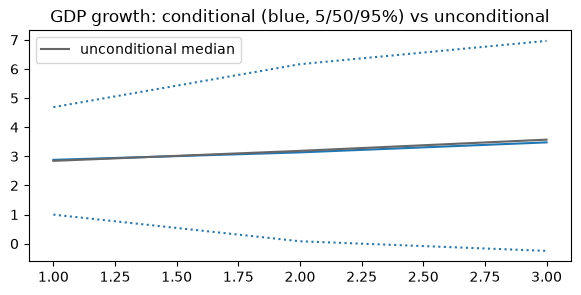

In [10]:
from macrotoolkit.postprocess import conditional_forecast_for_run
cf = conditional_forecast_for_run(run, {("pi", 0): 1.0, ("pi", 1): 1.0, ("pi", 2): 1.0}, horizon=3, draws_per_posterior_draw=2)
med = np.median(cf.draws, axis=0)
print("conditional median GDP-growth path:", np.round(med[:, 0], 3).tolist(), "| unconditional:", np.round(cf.unconditional[:, 0], 3).tolist())
print("the inflation path reproduces (1, 1, 1) to", f"{np.max(np.abs(cf.draws[:, :, 1] - 1.0)):.1e}")
fig, ax = plt.subplots(figsize=(7, 3))
for q, ls in ((0.05, ":"), (0.5, "-"), (0.95, ":")):
    ax.plot(range(1, 4), np.quantile(cf.draws[:, :, 0], q, axis=0), color="C0", linestyle=ls)
ax.plot(range(1, 4), cf.unconditional[:, 0], color="0.4", label="unconditional median")
ax.set_title("GDP growth: conditional (blue, 5/50/95%) vs unconditional"); ax.legend(); ax

## Examples 5–7: the 11-variable VAR with sign restrictions (heavy — a run session; set HANDBOOK_HEAVY=1)

In [11]:
run = heavy("ch2_signs_11var")
run.param_table().round(4) if run is not None else None

ch2_signs_11var: heavy example -- run with HANDBOOK_HEAVY=1 (a run session); skipped here.


In [12]:
if run is not None:
    from macrotoolkit.postprocess import SignRestriction, irf_array_from_draws, sign_restricted_irfs
    obs = tuple(run.results().meta.obs_names)
    arr, targets, shocks = irf_array_from_draws(run.outputs().compute("irf"), targets=obs)
    restr = [SignRestriction("mp", v, s, (0,)) for v, s in (("ffr", +1), ("gdp_growth", -1), ("cpi_inflation", -1), ("pce_growth", -1), ("unemployment", +1), ("investment", -1), ("m2", -1))]
    sr = sign_restricted_irfs(arr, restr, targets, np.random.default_rng(20260905), max_tries=2000)
    print(f"{sr.irf.shape[0]} of {arr.shape[0]} posterior draws accepted; median impact on gdp_growth {sr.bands('mp', 'gdp_growth')[1][0]:+.3f}")

In [13]:
plt.close("all")